# House Price Prediction - ML Pipeline
## София Кан | 11.06.2026

## 1. Постановка задачи

В данном проекте используется Ames Housing Dataset — датасет с информацией о жилых домах в городе Эймс, штат Айова. Он содержит различные характеристики недвижимости: площадь дома и участка, количество комнат, качество материалов, год постройки, состояние здания и так далее.

Целевая переменная - **SalePrice** - цена продажи дома. Необходимо построить модель, которая сможет по данным ей признакам предсказать стоимость определенного дома. 


Тип задачи: Регрессия

Метрики успеха:
- **MAE** - средняя абсолютная ошибка.
- **RMSE** - корень среднеквадратичной ошибки. 
- **R2** - доля общей вариации, объясненная моделью. 


## 2. Загрузка данных и первичный осмотр

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import matplotlib.ticker as ticker

In [88]:
housing_df = pd.read_csv('./datasets/AmesHousing.csv', index_col='Order')

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

housing_df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [89]:
housing_df.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [90]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 1 to 2930
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual     29

In [91]:
for i in housing_df.columns:
    result = f"{i}:  {(housing_df[i].notna().sum() / 2930) * 100} %"
    print(result)

PID:  100.0 %
MS SubClass:  100.0 %
MS Zoning:  100.0 %
Lot Frontage:  83.27645051194538 %
Lot Area:  100.0 %
Street:  100.0 %
Alley:  6.757679180887371 %
Lot Shape:  100.0 %
Land Contour:  100.0 %
Utilities:  100.0 %
Lot Config:  100.0 %
Land Slope:  100.0 %
Neighborhood:  100.0 %
Condition 1:  100.0 %
Condition 2:  100.0 %
Bldg Type:  100.0 %
House Style:  100.0 %
Overall Qual:  100.0 %
Overall Cond:  100.0 %
Year Built:  100.0 %
Year Remod/Add:  100.0 %
Roof Style:  100.0 %
Roof Matl:  100.0 %
Exterior 1st:  100.0 %
Exterior 2nd:  100.0 %
Mas Vnr Type:  39.419795221843 %
Mas Vnr Area:  99.2150170648464 %
Exter Qual:  100.0 %
Exter Cond:  100.0 %
Foundation:  100.0 %
Bsmt Qual:  97.26962457337885 %
Bsmt Cond:  97.26962457337885 %
Bsmt Exposure:  97.16723549488054 %
BsmtFin Type 1:  97.26962457337885 %
BsmtFin SF 1:  99.96587030716724 %
BsmtFin Type 2:  97.23549488054609 %
BsmtFin SF 2:  99.96587030716724 %
Bsmt Unf SF:  99.96587030716724 %
Total Bsmt SF:  99.96587030716724 %
Heating:

In [92]:
housing_df.dtypes.value_counts()

object     43
int64      27
float64    11
Name: count, dtype: int64

In [93]:
object_cols = housing_df.select_dtypes(include=['object']).columns.tolist()
num_cols = housing_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

housing_df[object_cols].nunique().sort_values(ascending=False)

Neighborhood      28
Exterior 2nd      17
Exterior 1st      16
Sale Type         10
Condition 1        9
House Style        8
Functional         8
Roof Matl          8
Condition 2        8
MS Zoning          7
Roof Style         6
BsmtFin Type 1     6
Sale Condition     6
Heating            6
Foundation         6
Garage Type        6
BsmtFin Type 2     6
Lot Config         5
Kitchen Qual       5
Misc Feature       5
Garage Cond        5
Garage Qual        5
Exter Cond         5
Fireplace Qu       5
Bsmt Cond          5
Bldg Type          5
Bsmt Qual          5
Heating QC         5
Electrical         5
Bsmt Exposure      4
Exter Qual         4
Land Contour       4
Lot Shape          4
Mas Vnr Type       4
Pool QC            4
Fence              4
Garage Finish      3
Land Slope         3
Utilities          3
Paved Drive        3
Alley              2
Street             2
Central Air        2
dtype: int64

## 3. EDA

In [ ]:
sns.set_style("darkgrid")

TARGET = "SalePrice"

PRETTY_NAMES = {
    "SalePrice": "Sale Price",
    "Overall Qual": "Overall Quality",
    "Gr Liv Area": "Above Ground Living Area",
    "Garage Cars": "Garage Cars",
    "Garage Area": "Garage Area",
    "Total Bsmt SF": "Basement Square Footage",
    "1st Flr SF": "1st Floor Square Footage",
    "Year Built": "Year Built",
    "Full Bath": "Full Bathrooms",
    "Year Remod/Add": "Remodel Year",
    "Mas Vnr Area": "Masonry Veneer Area",
    "TotRms AbvGrd": "Rooms Above Ground",
    "Fireplaces": "Number of Fireplaces",
    "BsmtFin SF 1": "Finished Basement Area Type 1",
    "Garage Yr Blt": "Garage Year Built",
    "Kitchen Qual": "Kitchen Quality",
    "Exter Qual": "Exterior Quality",
    "Bsmt Qual": "Basement Quality",
    "Fireplace Qu": "Fireplace Quality",
}


def pretty(col):
    return PRETTY_NAMES.get(col, col)


def apply_k_formatter(ax, axis="x"):
    def k_formatter(x, pos):
        return f"{int(x / 1000)}k"
    
    formatter = ticker.FuncFormatter(k_formatter)

    if axis == "x":
        ax.xaxis.set_major_formatter(formatter)
    elif axis == "y":
        ax.yaxis.set_major_formatter(formatter)


def make_axes(n_plots, n_cols=3, figsize=(16, 8), sharey=False):
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=figsize,
        sharey=sharey
    )
    axes = np.array(axes).flatten()

    for ax in axes[n_plots:]:
        ax.set_visible(False)

    return fig, axes

def plot_target_distribution(df, target=TARGET):
    plt.figure(figsize=(16, 9))

    ax = sns.histplot(
        data=df,
        x=target,
        kde=True
    )

    apply_k_formatter(ax, axis="x")

    plt.title("Distribution of Sale Price")
    plt.xlabel(pretty(target))
    plt.ylabel("Number of Houses")

    plt.show()

def get_top_correlations(df, target=TARGET, threshold=0.4):
    corr_with_target = (
        df
        .corr(numeric_only=True)[target]
        .drop(target)
        .sort_values(ascending=False)
    )

    top_corr = corr_with_target[
        (corr_with_target > threshold) | 
        (corr_with_target < -threshold)
    ]

    top_corr_df = (
        top_corr
        .reset_index()
        .rename(columns={
            "index": "Variable",
            target: "Correlation"
        })
    )

    top_corr_df["Variable"] = top_corr_df["Variable"].map(pretty)

    return top_corr_df

def plot_top_correlations(df, target=TARGET, threshold=0.4):
    top_corr = get_top_correlations(
        df=df,
        target=target,
        threshold=threshold
    )

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=top_corr,
        y="Variable",
        x="Correlation"
    )

    ax.set(ylabel=None)

    plt.title("Top Numerical Features Correlated with Sale Price", fontsize=14)
    plt.show()

    return top_corr

def plot_numeric_distributions(
    df,
    features,
    n_cols=5,
    figsize=(20, 10),
    k_format_cols=None,
    title=None
):
    if k_format_cols is None:
        k_format_cols = []

    fig, axes = make_axes(
        n_plots=len(features),
        n_cols=n_cols,
        figsize=figsize
    )

    for ax, col in zip(axes, features):
        sns.histplot(
            data=df,
            x=col,
            ax=ax
        )

        ax.set_xlabel(pretty(col))
        ax.set_ylabel("Count")

        if col in k_format_cols:
            apply_k_formatter(ax, axis="x")

    if title:
        fig.suptitle(title, fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()

def get_categorical_importance(df, categorical_cols, target=TARGET, min_count=10):
    cat_importance = []

    for col in categorical_cols:
        grouped = df.groupby(col)[target].agg(["count", "median"])

        grouped = grouped[grouped["count"] >= min_count]

        if len(grouped) > 1:
            score = grouped["median"].max() - grouped["median"].min()
        else:
            score = 0

        cat_importance.append({
            "Variable": col,
            "Unique values": df[col].nunique(),
            "Useful categories": len(grouped),
            "Median SalePrice range": score
        })

    cat_importance_df = pd.DataFrame(cat_importance).sort_values(
        "Median SalePrice range",
        ascending=False
    )

    return cat_importance_df

def plot_categorical_counts(
    df,
    features,
    n_cols=5,
    figsize=(20, 10),
    orders=None,
    horizontal_cols=None,
    title=None
):
    if orders is None:
        orders = {}

    if horizontal_cols is None:
        horizontal_cols = []

    fig, axes = make_axes(
        n_plots=len(features),
        n_cols=n_cols,
        figsize=figsize
    )

    for ax, col in zip(axes, features):
        order = orders.get(col, df[col].value_counts().index)

        if col in horizontal_cols:
            sns.countplot(
                data=df,
                y=col,
                order=order,
                ax=ax
            )

            ax.set_xlabel("Count")
            ax.set_ylabel(pretty(col))

        else:
            sns.countplot(
                data=df,
                x=col,
                order=order,
                ax=ax
            )

            ax.set_xlabel(pretty(col))
            ax.set_ylabel("Count")
            ax.tick_params(axis="x", rotation=45)

    if title:
        fig.suptitle(title, fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()


def plot_numeric_vs_target(
    df,
    features,
    target=TARGET,
    n_cols=2,
    figsize=(14, 9)
):
    fig, axes = make_axes(
        n_plots=len(features),
        n_cols=n_cols,
        figsize=figsize,
        sharey=True
    )

    for i, (ax, col) in enumerate(zip(axes, features)):
        corr = df[[col, target]].corr().iloc[0, 1]

        sns.regplot(
            data=df,
            x=col,
            y=target,
            ax=ax,
            scatter_kws={
                "alpha": 0.2,
                "s": 35,
                "edgecolor": "none"
            },
            line_kws={
                "linewidth": 2
            },
            ci=None
        )

        ax.set_title(
            f"{pretty(col)} vs {pretty(target)}\nCorrelation: {corr:.2f}",
            fontsize=12
        )

        ax.set_xlabel(pretty(col), fontsize=10)
        ax.set_ylabel(pretty(target) if i % n_cols == 0 else "")

        apply_k_formatter(ax, axis="y")

    fig.suptitle(
        "Relationship Between Key Numerical Features and Sale Price",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


def plot_boxplots_vs_target(
    df,
    features,
    target=TARGET,
    n_cols=2,
    figsize=(14, 9),
    title=None
):
    fig, axes = make_axes(
        n_plots=len(features),
        n_cols=n_cols,
        figsize=figsize,
        sharey=True
    )

    for i, (ax, col) in enumerate(zip(axes, features)):
        sns.boxplot(
            data=df,
            x=col,
            y=target,
            ax=ax
        )

        ax.set_title(
            f"{pretty(target)} by {pretty(col)}",
            fontsize=12
        )

        ax.set_xlabel(pretty(col), fontsize=10)
        ax.set_ylabel(pretty(target) if i % n_cols == 0 else "")

        apply_k_formatter(ax, axis="y")

    if title:
        fig.suptitle(title, fontsize=16, y=1.02)

    plt.tight_layout()
    plt.show()


def plot_pairplot_by_price_category(
    df,
    features,
    target=TARGET,
    q=3,
    labels=None
):
    if labels is None:
        labels = ["Low", "Medium", "High"]

    pairplot_df = df[features + [target]].copy()

    pairplot_df["Price Category"] = pd.qcut(
        pairplot_df[target],
        q=q,
        labels=labels
    )

    pairplot_df = pairplot_df.drop(columns=[target])

    pairplot_df = pairplot_df.rename(
        columns={col: pretty(col) for col in pairplot_df.columns}
    )

    g = sns.pairplot(
        pairplot_df,
        hue="Price Category",
        height=2.4,
        diag_kind="kde"
    )

    g.fig.suptitle(
        "Relationships Between Key Features by Price Category",
        y=1.03,
        fontsize=16
    )

    plt.show()


def plot_percentage_crosstab_heatmap(
    df,
    row_col,
    col_col,
    figsize=(14, 8),
    cmap="Blues",
    title=None
):
    cross_tab = pd.crosstab(
        df[row_col],
        df[col_col],
        normalize="index"
    ) * 100

    annot_labels = cross_tab.map(
        lambda x: f"{x:.0f}%" if x != 0 else ""
    )

    plt.figure(figsize=figsize)

    sns.heatmap(
        cross_tab,
        cmap=cmap,
        annot=annot_labels,
        fmt=""
    )

    if title is None:
        title = f"{pretty(col_col)} Distribution by {pretty(row_col)} (%)"

    plt.title(title)
    plt.xlabel(pretty(col_col))
    plt.ylabel(pretty(row_col))

    plt.show()

    return cross_tab


def plot_top_corr_heatmap(
    df,
    target=TARGET,
    n_features=15,
    figsize=(14, 10)
):
    corr_matrix = df.corr(numeric_only=True)

    top_corr_features = (
        corr_matrix[target]
        .drop(target)
        .abs()
        .sort_values(ascending=False)
        .head(n_features)
        .index
    )

    selected_cols = [target] + top_corr_features.tolist()

    plt.figure(figsize=figsize)

    sns.heatmap(
        df[selected_cols].corr(),
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        linewidths=0.5
    )

    plt.title("Correlation Heatmap of Top Numeric Features Related to Sale Price")
    plt.show()


def get_high_corr_pairs(df, numeric_cols, threshold=0.8):
    corr_matrix = df[numeric_cols].corr().abs()

    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    high_corr_pairs = (
        upper_triangle
        .stack()
        .sort_values(ascending=False)
    )

    return high_corr_pairs[high_corr_pairs > threshold]


def check_structured_missingness(df, missing_col, condition_col, expected_value=0):
    missing_mask = df[missing_col].isna()

    percent = (
        df.loc[missing_mask, condition_col]
        .eq(expected_value)
        .mean()
        * 100
    )

    print(
        f"{missing_col}: {percent:.2f}% of missing values correspond to "
        f"{condition_col} = {expected_value}"
    )

    return percent


def check_multiple_structured_missingness(
    df,
    missing_cols,
    condition_col,
    expected_value=0
):
    results = {}

    for col in missing_cols:
        results[col] = check_structured_missingness(
            df=df,
            missing_col=col,
            condition_col=condition_col,
            expected_value=expected_value
        )

    return pd.Series(results).sort_values(ascending=False)


### Распределение целевой переменной

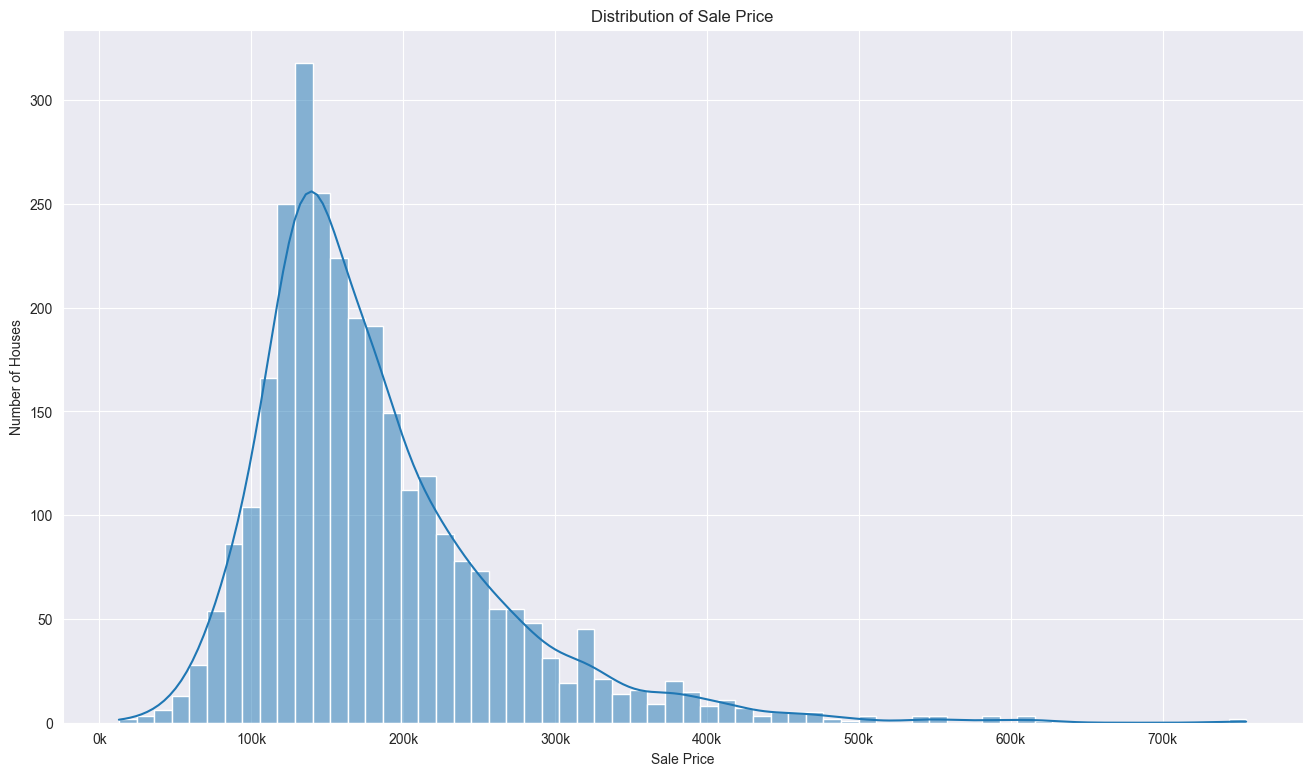

In [95]:
sns.set_style('darkgrid')

plt.figure(figsize=(16, 9))
ax = sns.histplot(housing_df['SalePrice'], kde=True)
apply_k_formatter(ax, axis="x")


plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

### Числовые признаки с средней и высокой корреляцией с целевой переменной:

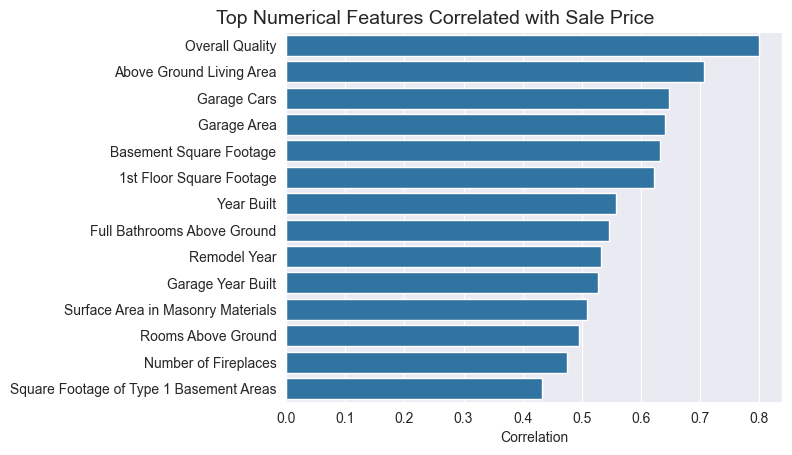

In [96]:
corr_with_target = housing_df[num_cols].corr()["SalePrice"].sort_values(ascending=False)

top_corr = corr_with_target[
    (corr_with_target > 0.4) | (corr_with_target < -0.4)
]
top_corr = top_corr.drop(top_corr[top_corr == 1].index)
top_corr = top_corr.to_frame()
top_corr = top_corr.reset_index()
top_corr.columns = ['Variable', 'Correlation']

name_map = {
    'Overall Qual': 'Overall Quality',
    'Gr Liv Area': 'Above Ground Living Area',
    'Garage Cars': 'Garage Cars',
    'Garage Area': 'Garage Area',
    'Total Bsmt SF': 'Basement Square Footage',
    '1st Flr SF': '1st Floor Square Footage',
    'Year Built': 'Year Built',
    'Full Bath': 'Full Bathrooms Above Ground',
    'Year Remod/Add': 'Remodel Year',
    'Mas Vnr Area': 'Surface Area in Masonry Materials',
    'TotRms AbvGrd': 'Rooms Above Ground',
    'Fireplaces': 'Number of Fireplaces',
    'BsmtFin SF 1': 'Square Footage of Type 1 Basement Areas',
    'Garage Yr Blt': 'Garage Year Built'
}

top_corr['Variable'] = top_corr['Variable'].replace(name_map)

ax = sns.barplot(data=top_corr, y='Variable', x='Correlation')
ax.set(ylabel=None)

plt.title("Top Numerical Features Correlated with Sale Price", fontsize=14, x=0.3)

plt.show()

### Распределения 10 числовых признаков с самой высокой корреляцией с целевой переменной:

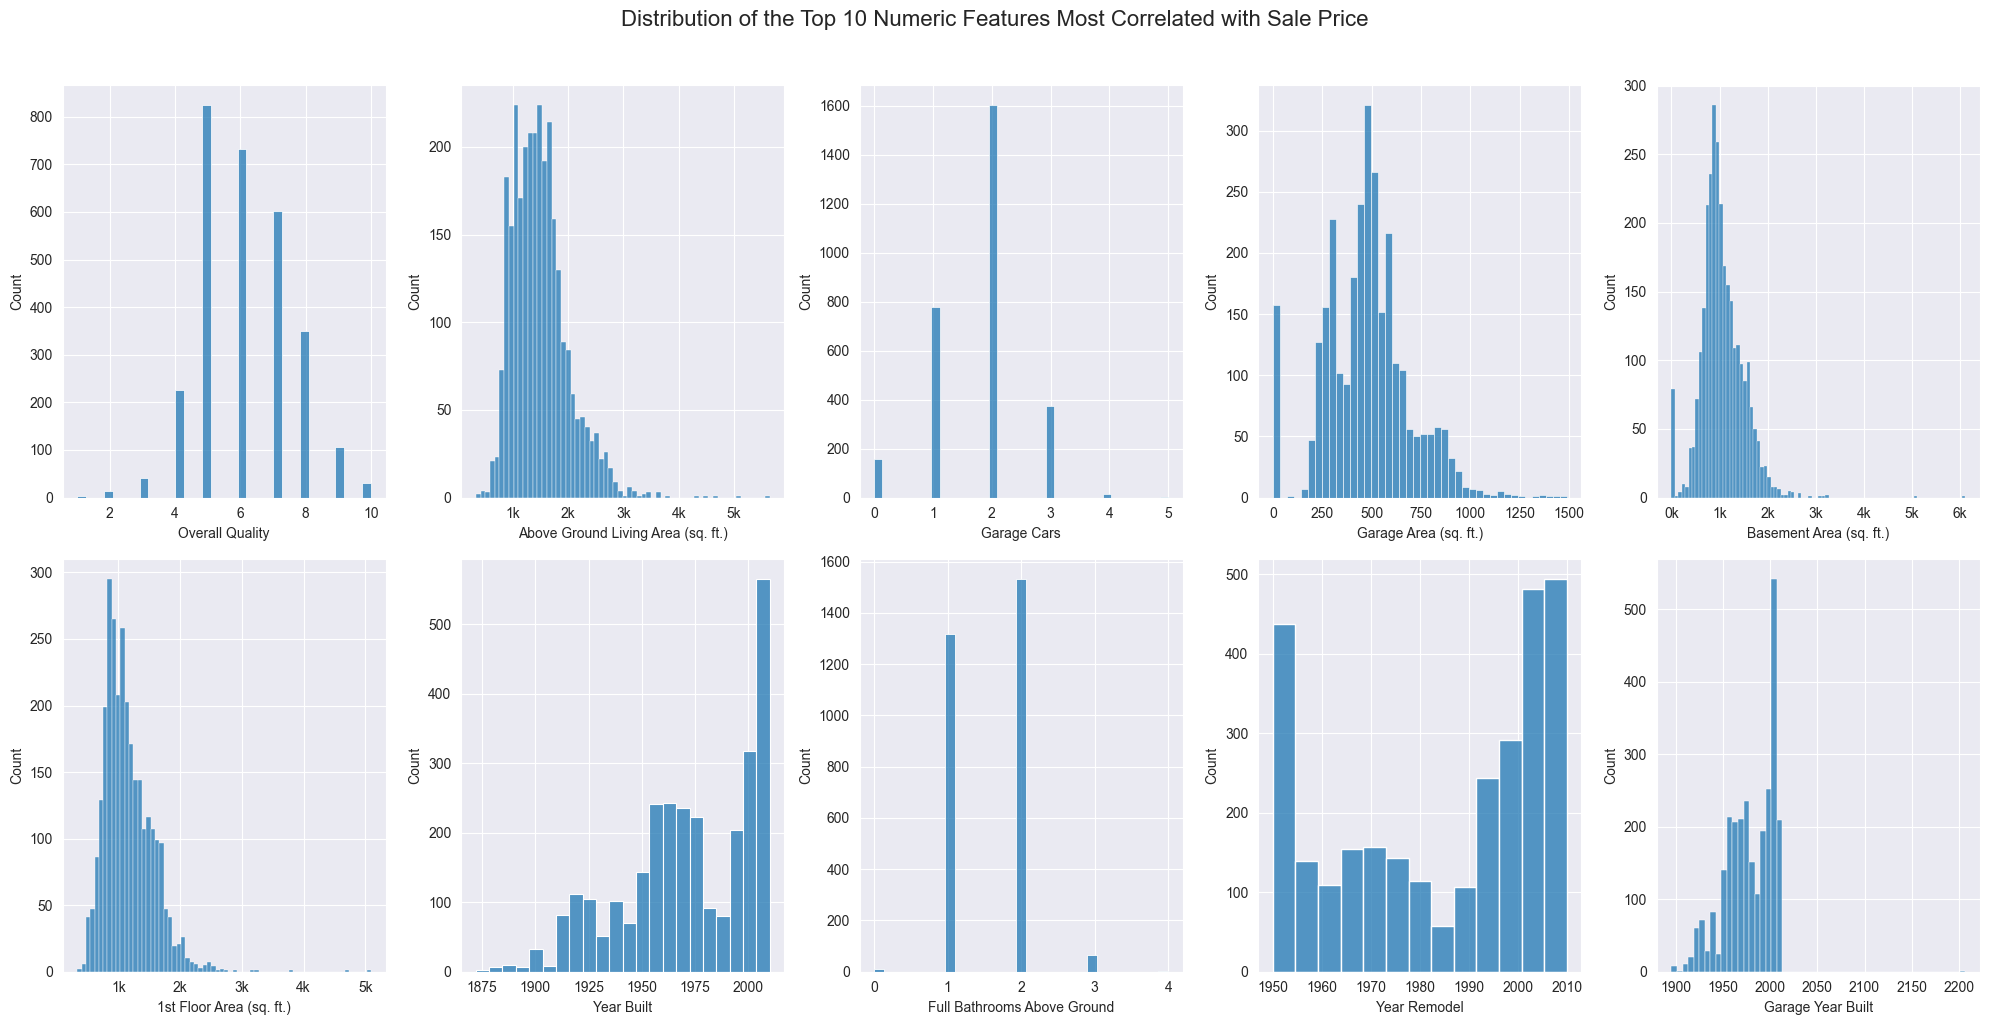

In [97]:
features = [
    ("Overall Qual", "Overall Quality"),
    ("Gr Liv Area", "Above Ground Living Area (sq. ft.)"),
    ("Garage Cars", "Garage Cars"),
    ("Garage Area", "Garage Area (sq. ft.)"),
    ("Total Bsmt SF", "Basement Area (sq. ft.)"),
    ("1st Flr SF", "1st Floor Area (sq. ft.)"),
    ("Year Built", "Year Built"),
    ("Full Bath", "Full Bathrooms Above Ground"),
    ("Year Remod/Add", "Year Remodel"),
    ("Garage Yr Blt", "Garage Year Built")
]

sqft_features = [
    "Gr Liv Area",
    "Total Bsmt SF",
    "1st Flr SF"
]

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for ax, (col, label) in zip(axes, features):
    sns.histplot(data=housing_df[col], ax=ax)
    ax.set_xlabel(label)
    
    if col in sqft_features:
        apply_k_formatter(ax, axis="x")

fig.suptitle(
    "Distribution of the Top 10 Numeric Features Most Correlated with Sale Price",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

HIGHLY INTERESTING, GARAGE BUILT IN 2207 :)

In [98]:
housing_df[housing_df['Garage Yr Blt'] > 2100]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2261,916384070,20,RL,68.0,8298,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,Timber,Norm,Norm,1Fam,1Story,8,5,2006,2007,Hip,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,Av,GLQ,583.0,Unf,0.0,963.0,1546.0,GasA,Ex,Y,SBrkr,1564,0,0,1564,0.0,0.0,2,0,2,1,Ex,6,Typ,1,Gd,Attchd,2207.0,RFn,2.0,502.0,TA,TA,Y,132,0,0,0,0,0,NaN,NaN,NaN,0,9,2007,New,Partial,267300


### Распределения 10 категориальных признаков с наибольшей разницей в медианной цене продажи

In [99]:
cat_importance = []

for col in object_cols:
    grouped = housing_df.groupby(col)["SalePrice"].agg(["count", "median"])
    
    grouped = grouped[grouped["count"] >= 10]  
    
    if len(grouped) > 1:
        score = grouped["median"].max() - grouped["median"].min()
    else:
        score = 0
    
    cat_importance.append({
        "Variable": col,
        "Unique values": housing_df[col].nunique(),
        "Useful categories": len(grouped),
        "Median SalePrice range": score
    })

cat_importance_df = pd.DataFrame(cat_importance).sort_values(
    "Median SalePrice range", 
    ascending=False
)

cat_importance_df.head(15)

,Variable,Unique values,Useful categories,Median SalePrice range
18,Exter Qual,4,4,285967.0
8,Neighborhood,28,25,230750.0
30,Kitchen Qual,5,4,217874.0
21,Bsmt Qual,5,4,217500.0
32,Fireplace Qu,5,5,184500.0
42,Sale Condition,6,6,140000.0
0,MS Zoning,7,5,131000.0
15,Exterior 1st,16,10,130000.0
33,Garage Type,6,6,127600.0
16,Exterior 2nd,17,12,127500.0


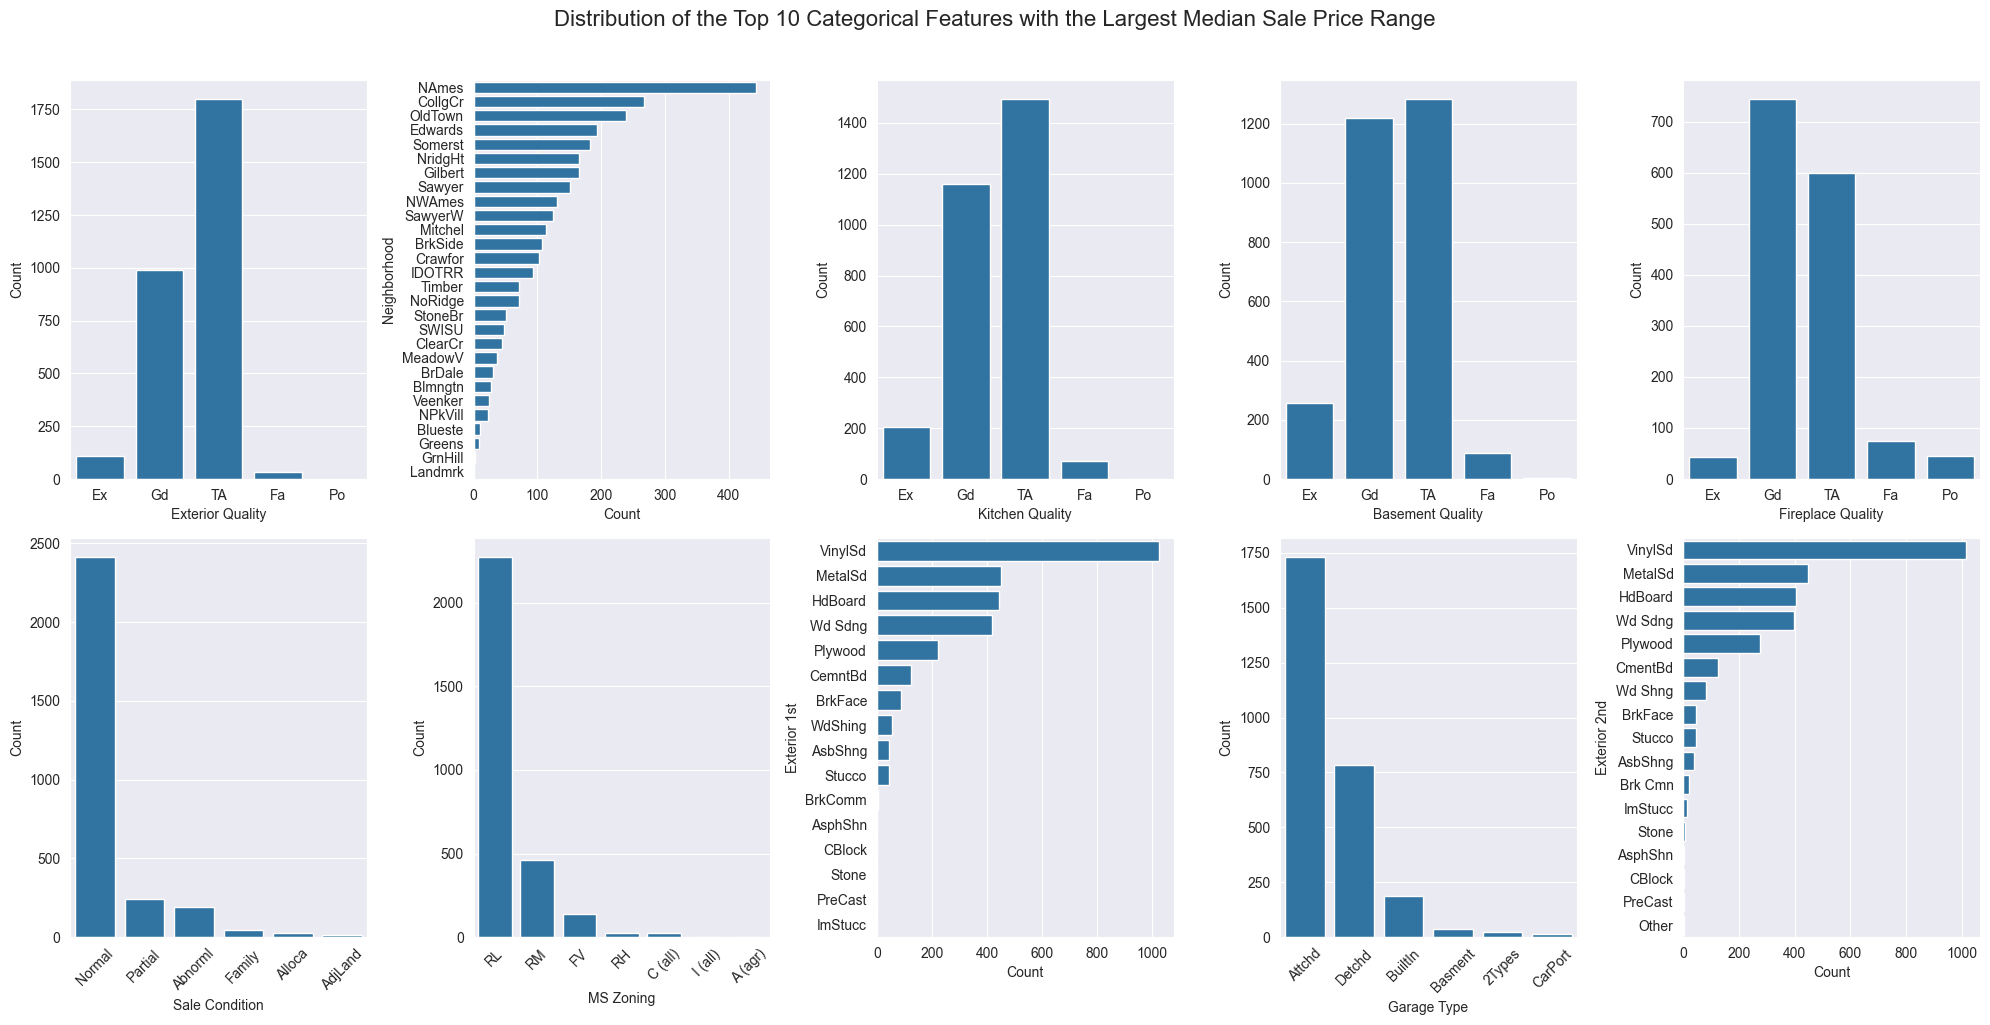

In [100]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

quality_order = ["Ex", "Gd", "TA", "Fa", "Po"]

# Exterior Quality
sns.countplot(
    data=housing_df,
    x='Exter Qual',
    order=quality_order,
    ax=axes[0, 0]
)
axes[0, 0].set_xlabel('Exterior Quality')
axes[0, 0].set_ylabel('Count')

# Neighborhood
sns.countplot(
    data=housing_df,
    y='Neighborhood',
    order=housing_df['Neighborhood'].value_counts().index,
    ax=axes[0, 1]
)
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Neighborhood')

# Kitchen Quality
sns.countplot(
    data=housing_df,
    x='Kitchen Qual',
    order=quality_order,
    ax=axes[0, 2]
)
axes[0, 2].set_xlabel('Kitchen Quality')
axes[0, 2].set_ylabel('Count')

# Basement Quality
sns.countplot(
    data=housing_df,
    x='Bsmt Qual',
    order=quality_order,
    ax=axes[0, 3]
)
axes[0, 3].set_xlabel('Basement Quality')
axes[0, 3].set_ylabel('Count')

# Fireplace Quality
sns.countplot(
    data=housing_df,
    x='Fireplace Qu',
    order=quality_order,
    ax=axes[0, 4]
)
axes[0, 4].set_xlabel('Fireplace Quality')
axes[0, 4].set_ylabel('Count')

# Sale Condition
sns.countplot(
    data=housing_df,
    x='Sale Condition',
    order=housing_df['Sale Condition'].value_counts().index,
    ax=axes[1, 0]
)
axes[1, 0].set_xlabel('Sale Condition')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# MS Zoning
sns.countplot(
    data=housing_df,
    x='MS Zoning',
    order=housing_df['MS Zoning'].value_counts().index,
    ax=axes[1, 1]
)
axes[1, 1].set_xlabel('MS Zoning')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

# Exterior 1st
sns.countplot(
    data=housing_df,
    y='Exterior 1st',
    order=housing_df['Exterior 1st'].value_counts().index,
    ax=axes[1, 2]
)
axes[1, 2].set_xlabel('Count')
axes[1, 2].set_ylabel('Exterior 1st')

# Garage Type
sns.countplot(
    data=housing_df,
    x='Garage Type',
    order=housing_df['Garage Type'].value_counts().index,
    ax=axes[1, 3]
)
axes[1, 3].set_xlabel('Garage Type')
axes[1, 3].set_ylabel('Count')
axes[1, 3].tick_params(axis='x', rotation=45)

# Exterior 2nd
sns.countplot(
    data=housing_df,
    y='Exterior 2nd',
    order=housing_df['Exterior 2nd'].value_counts().index,
    ax=axes[1, 4]
)
axes[1, 4].set_xlabel('Count')
axes[1, 4].set_ylabel('Exterior 2nd')

fig.suptitle(
    "Distribution of the Top 10 Categorical Features with the Largest Median Sale Price Range",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Визуализация отношений признаков с целевой переменной

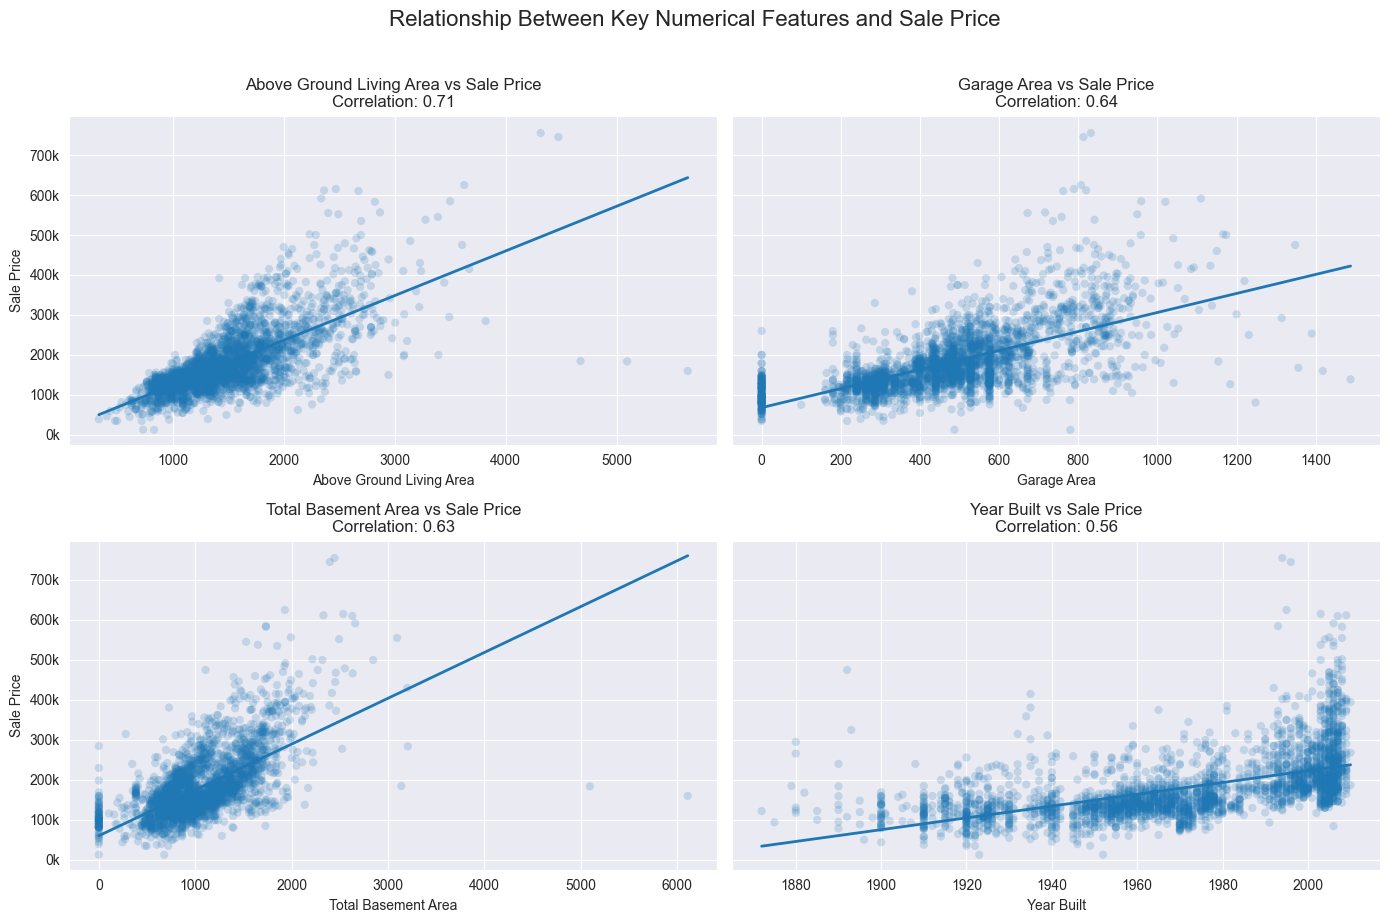

In [115]:
target = "SalePrice"

continuous_features = [
    "Gr Liv Area",
    "Garage Area",
    "Total Bsmt SF",
    "Year Built",
]

pretty_names = {
    "Gr Liv Area": "Above Ground Living Area",
    "Garage Area": "Garage Area",
    "Total Bsmt SF": "Total Basement Area",
    "Year Built": "Year Built",
    "SalePrice": "Sale Price"
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9),
    sharey=True
)

axes = axes.flatten()

for ax, col in zip(axes, continuous_features):
    corr = housing_df[[col, target]].corr().iloc[0, 1]
    
    sns.regplot(
        data=housing_df,
        x=col,
        y=target,
        ax=ax,
        scatter_kws={
            "alpha": 0.2,
            "s": 35,
            "edgecolor": "none"
        },
        line_kws={
            "linewidth": 2
        },
        ci=None
    )
    
    ax.set_title(
        f"{pretty_names[col]} vs Sale Price\nCorrelation: {corr:.2f}",
        fontsize=12
    )
    
    ax.set_xlabel(pretty_names[col], fontsize=10)
    ax.set_ylabel("Sale Price" if ax in [axes[0], axes[2]] else "")
    
    apply_k_formatter(ax=ax, axis="y")

fig.suptitle(
    "Relationship Between Key Numerical Features and Sale Price",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

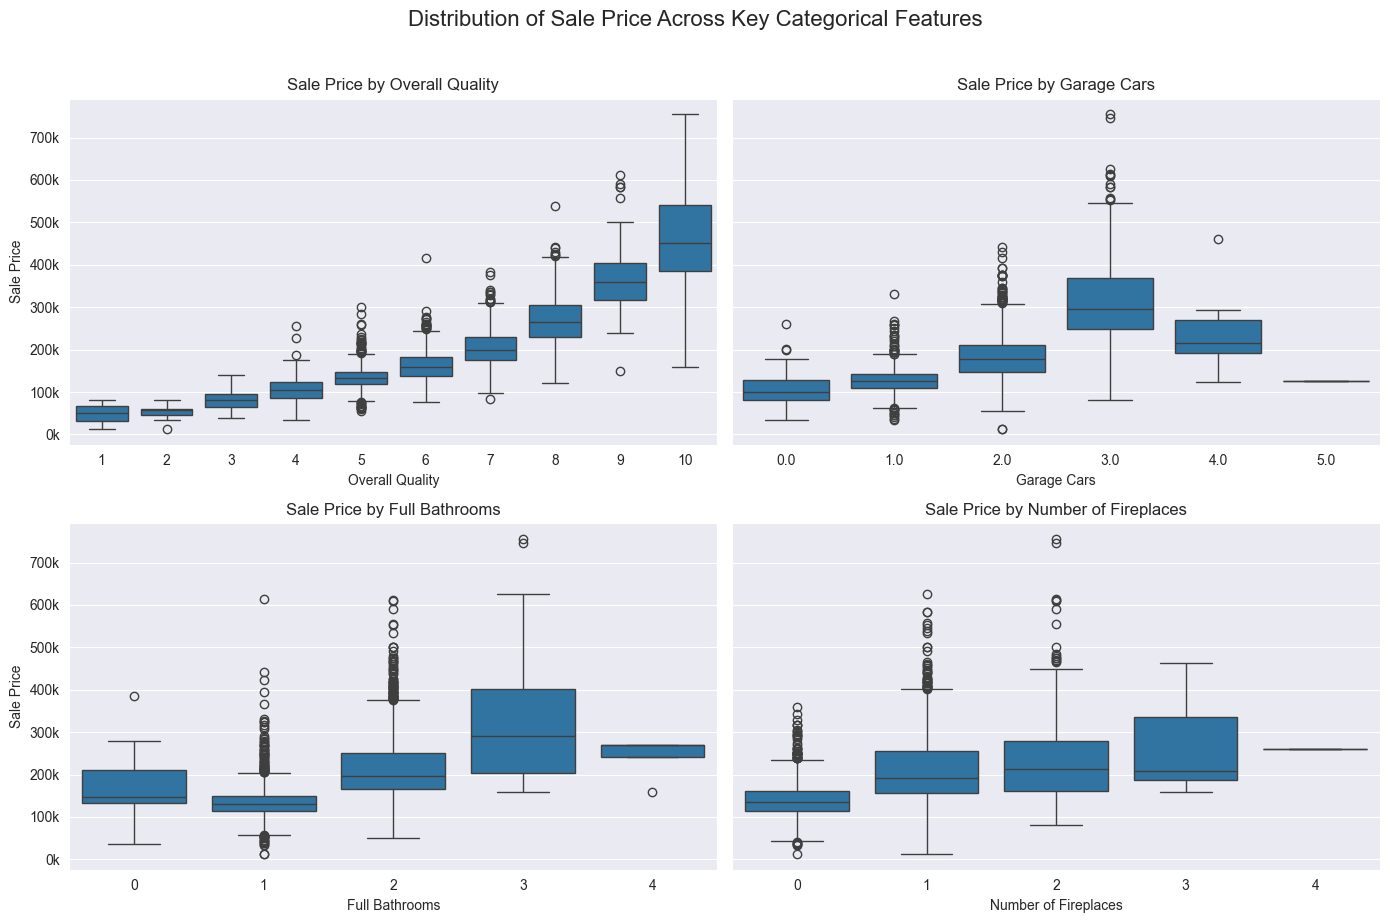

In [121]:
discrete_features = [
    "Overall Qual",
    "Garage Cars",
    "Full Bath",
    "Fireplaces"
]

pretty_names = {
    "Overall Qual": "Overall Quality",
    "Garage Cars": "Garage Cars",
    "Full Bath": "Full Bathrooms",
    "Fireplaces": "Number of Fireplaces"
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9),
    sharey=True
)

axes = axes.flatten()

for ax, col in zip(axes, discrete_features):
    sns.boxplot(
        data=housing_df,
        x=col,
        y=target,
        ax=ax
    )
    
    median_prices = housing_df.groupby(col)[target].median()
    
    ax.set_title(
        f"Sale Price by {pretty_names[col]}",
        fontsize=12
    )
    
    ax.set_xlabel(pretty_names[col], fontsize=10)
    ax.set_ylabel("Sale Price" if ax in [axes[0], axes[2]] else "")
    
    apply_k_formatter(ax=ax, axis="y")

fig.suptitle(
    "Distribution of Sale Price Across Key Categorical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Визуализации отношений между признаками

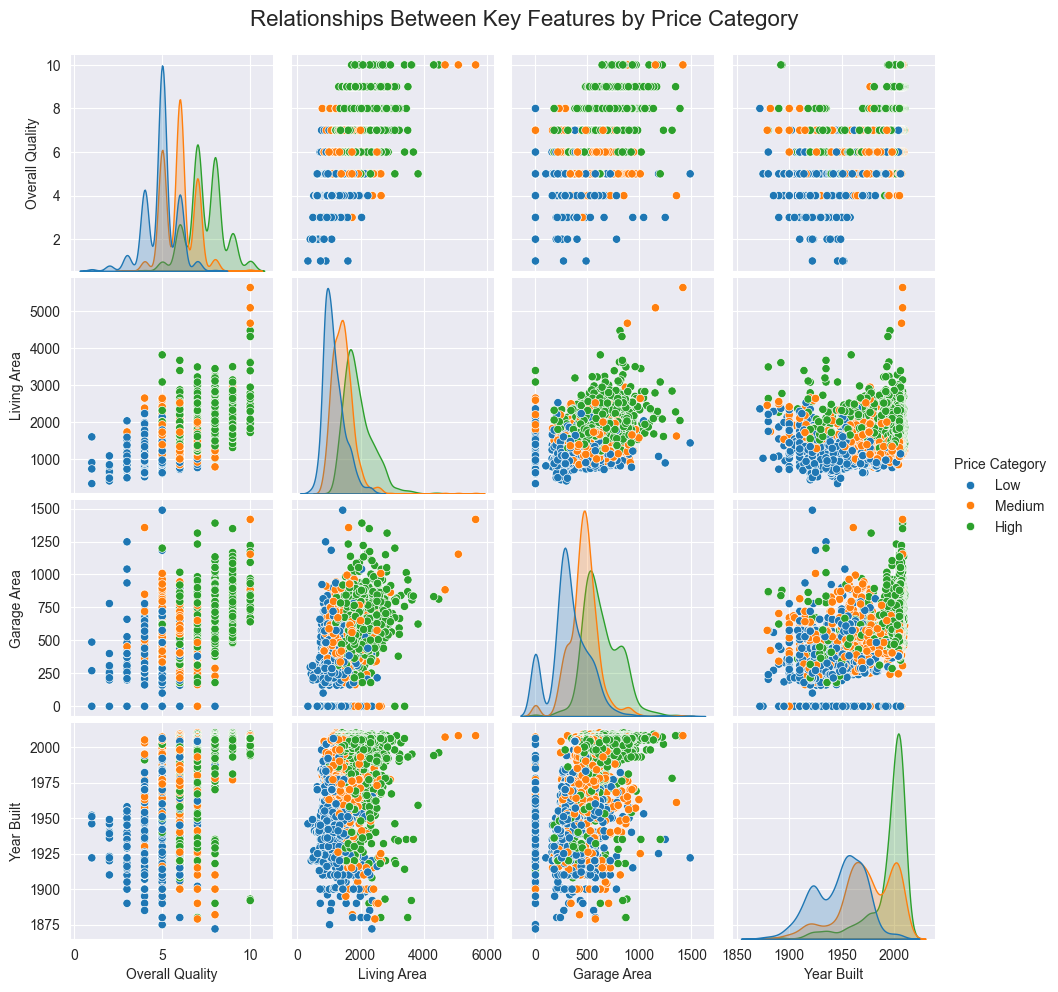

In [123]:
housing_df["Price Category"] = pd.qcut(
    housing_df["SalePrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

selected_cols = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Area",
    "Year Built",
    "Price Category"
]

pairplot_df = housing_df[selected_cols].rename(columns={
    "Overall Qual": "Overall Quality",
    "Gr Liv Area": "Living Area",
    "Garage Area": "Garage Area",
    "Year Built": "Year Built",
    "Price Category": "Price Category"
})

g = sns.pairplot(
    pairplot_df,
    hue="Price Category",
    height=2.4,
    diag_kind="kde"
)

g.fig.suptitle(
    "Relationships Between Key Features by Price Category",
    y=1.03,
    fontsize=16
)

plt.show()

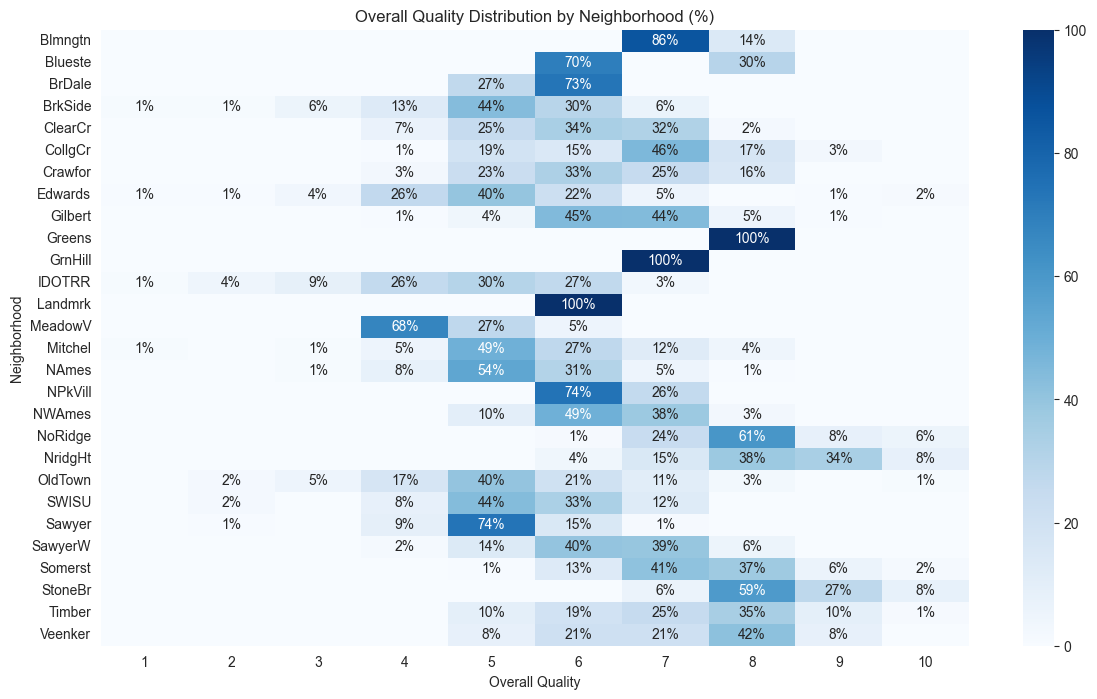

In [133]:
cross_tab = pd.crosstab(
    housing_df["Neighborhood"],
    housing_df["Overall Qual"],
    normalize="index"
) * 100

annot_labels = cross_tab.map(lambda x: f"{x:.0f}%" if x != 0 else "")

plt.figure(figsize=(14, 8))

sns.heatmap(
    cross_tab,
    cmap="Blues",
    annot=annot_labels,
    fmt=""
)

plt.title("Overall Quality Distribution by Neighborhood (%)")
plt.xlabel("Overall Quality")
plt.ylabel("Neighborhood")

plt.show()

### Корреляционная матрица числовых признаков

такая, потому что если строить полную, то получается матрица 38 х 38 = 1444 значений

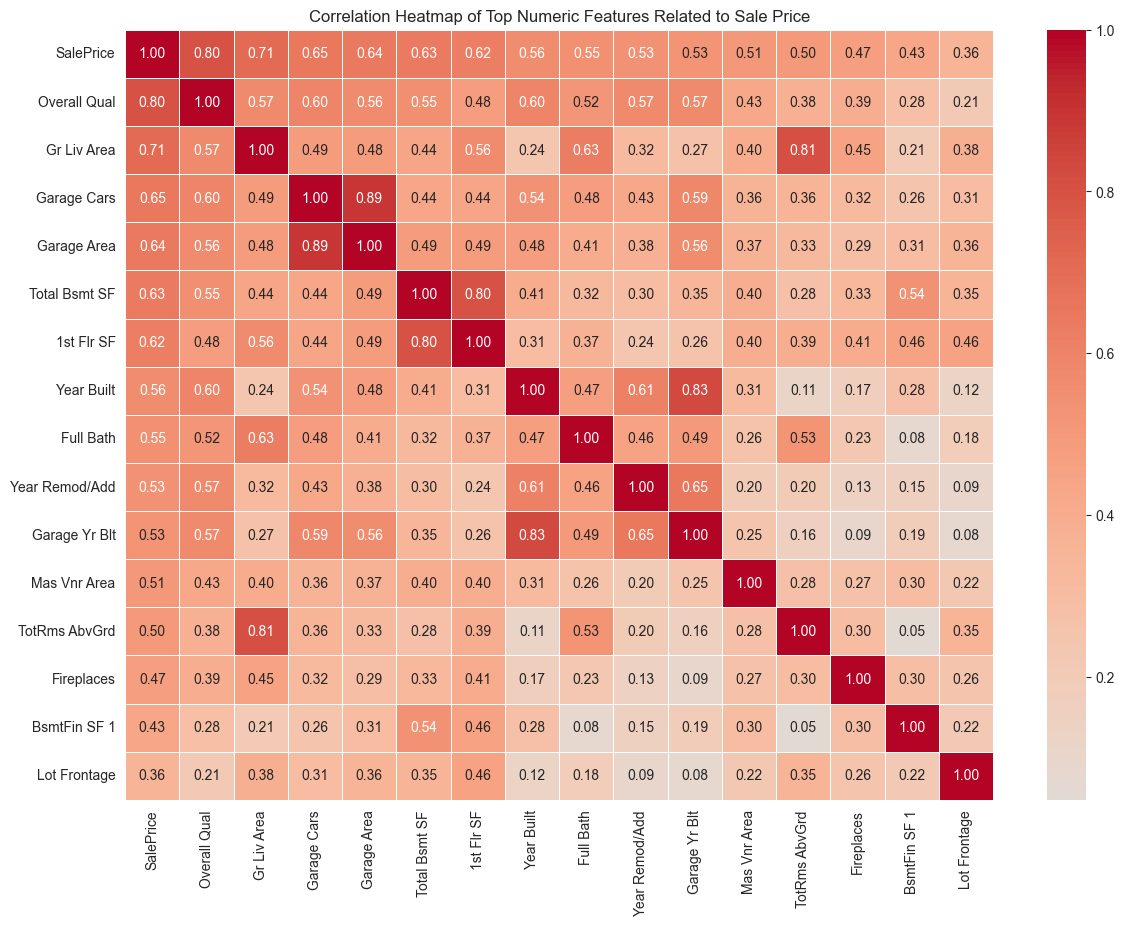

In [105]:
target = "SalePrice"

corr_matrix = housing_df.corr(numeric_only=True)

top_corr_features = (
    corr_matrix[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

selected_cols = [target] + top_corr_features.tolist()

plt.figure(figsize=(14, 10))

sns.heatmap(
    housing_df[selected_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Top Numeric Features Related to Sale Price")
plt.show()

Multicollinearity

In [134]:
corr_matrix = housing_df[num_cols].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs[high_corr_pairs > 0.8]

Garage Cars    Garage Area      0.889676
Year Built     Garage Yr Blt    0.834849
Gr Liv Area    TotRms AbvGrd    0.807772
Total Bsmt SF  1st Flr SF       0.800720
dtype: float64

In [106]:
print(num_cols) ## check for unusual cols

['PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']


### Выводы:

## 4. Предобработка

    - Обработка пропусков
    - Кодирование категориальных переменных
    - Масштабирование
    - Feature engineering
    - PCA
    - Data leakage, highly corr features (check gauss-markov for linreg)

    - Outlier management / unusual nums in rows
    - typos for categorical


### Structured Missingness

Not 100 percentages:

// No basement? 
- Basement finished area 1: 99.96587030716724 %
- Basement finished area 2: 99.96587030716724 %
- Basement unfinished area: 99.96587030716724 %
- Basement quality: 97.26962457337885 %
- Basement condition: 97.26962457337885 %
- Basement finished type 1: 97.26962457337885 %
- Basement finished type 2: 97.23549488054609 %
- Basement exposure: 97.16723549488054 %
- Basement full bathrooms: 99.93174061433447 %
- Basement half bathrooms: 99.93174061433447 %


- Total basement area: 99.96587030716724 %
- Electrical system: 99.96587030716724 %

/// Maybe no Garage? 
- Garage car capacity: 99.96587030716724 %
- Garage area: 99.96587030716724 %
- Garage type: 94.64163822525597 %
- Garage year built: 94.57337883959043 %
- Garage finish: 94.57337883959043 %
- Garage quality: 94.57337883959043 %
- Garage condition: 94.57337883959043 %

// No fireplace?
- Fireplace quality: 51.46757679180888 %


- Masonry veneer area: 99.2150170648464 %
- Masonry veneer type: 39.419795221843 %

- Pool quality: 0.4436860068259386 %

- Fence quality: 19.522184300341298 %

- Lot frontage: 83.27645051194538 %
- Alley access: 6.757679180887371 %
- Miscellaneous feature: 3.6177474402730376 %

In [107]:
housing_df.loc[
    housing_df["Fireplace Qu"].isna(),
    "Fireplaces"
].value_counts(dropna=False)

missing_fireplace_qu = housing_df["Fireplace Qu"].isna()

(housing_df.loc[missing_fireplace_qu, "Fireplaces"] == 0).mean() * 100

np.float64(100.0)

In [108]:
bsmt_cols = [
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2"
]

for col in bsmt_cols:
    missing = housing_df[col].isna()
    percent_no_basement = (housing_df.loc[missing, "Total Bsmt SF"] == 0).mean() * 100
    
    print(col, ":", percent_no_basement)

Bsmt Qual : 98.75
Bsmt Cond : 98.75
Bsmt Exposure : 95.18072289156626
BsmtFin Type 1 : 98.75
BsmtFin Type 2 : 97.53086419753086


In [109]:
missing_pool_qc = housing_df["Pool QC"].isna()

(housing_df.loc[missing_pool_qc, "Pool Area"] == 0).mean() * 100

np.float64(100.0)

In [110]:
housing_df["Fence"].isna().value_counts()
housing_df["Alley"].isna().value_counts()
housing_df["Misc Feature"].isna().value_counts()

Misc Feature
True     2824
False     106
Name: count, dtype: int64

In [111]:
housing_df[(housing_df['Garage Type'].isna()) & (housing_df['Garage Cars'].notna())]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Price Category
Order,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
28,527425090,20,RL,70.0,10500,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,NAmes,Norm,Norm,1Fam,1Story,4,5,1971,1971,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,432.0,Unf,0.0,432.0,864.0,GasA,TA,Y,SBrkr,864,0,0,864,0.0,0.0,1,0,3,1,TA,5,Typ,1,Po,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,ConLI,Normal,115000,Low
120,534276360,20,RL,77.0,9320,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,4,5,1959,1959,Gable,CompShg,Plywood,Plywood,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,569.0,Unf,0.0,381.0,950.0,GasA,Fa,Y,SBrkr,1225,0,0,1225,1.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,352,0,0,0,0,0,NaN,NaN,Shed,400,1,2010,WD,Normal,128950,Low
126,534427010,90,RL,98.0,13260,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,Duplex,1Story,5,6,1962,2001,Hip,CompShg,HdBoard,HdBoard,BrkFace,144.0,TA,TA,CBlock,TA,TA,No,BLQ,1500.0,Unf,0.0,228.0,1728.0,GasA,TA,Y,SBrkr,1728,0,0,1728,2.0,0.0,2,0,6,2,TA,10,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,1,2010,Oth,Abnorml,84900,Low
130,534450180,20,RL,50.0,7207,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,1Story,5,7,1958,2008,Gable,CompShg,Wd Sdng,Plywood,NaN,0.0,TA,Gd,CBlock,TA,TA,Gd,BLQ,696.0,Unf,0.0,162.0,858.0,GasA,Gd,Y,SBrkr,858,0,0,858,1.0,0.0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,117,0,0,0,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal,116500,Low
131,534451150,30,RL,55.0,5350,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,1Story,3,2,1940,1966,Gable,CompShg,Wd Sdng,Plywood,NaN,0.0,TA,Po,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,728.0,728.0,GasA,Ex,Y,SBrkr,1306,0,0,1306,0.0,0.0,1,0,3,1,Fa,6,Mod,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,263,0,0,0,0,0,NaN,GdWo,Shed,450,5,2010,WD,Normal,76500,Low
171,902104060,50,RM,55.0,8800,Pave,Grvl,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Norm,Norm,1Fam,1.5Fin,4,7,1910,2004,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,BrkTil,TA,Fa,No,Unf,0.0,Unf,0.0,576.0,576.0,GasA,Gd,Y,SBrkr,792,348,0,1140,0.0,0.0,1,0,3,1,TA,7,Min2,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,N,0,160,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,96500,Low
172,902106130,30,RM,56.0,4485,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1Story,5,7,1920,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,PConc,TA,TA,No,BLQ,579.0,Unf,0.0,357.0,936.0,GasA,TA,Y,SBrkr,936,0,0,936,1.0,0.0,1,0,2,1,TA,5,Typ,1,Gd,NaN,NaN,NaN,0.0,0.0,NaN,NaN,P,51,0,135,0,0,0,NaN,MnPrv,NaN,0,5,2010,WD,Normal,109500,Low
187,902401060,190,RM,100.0,9045,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,2fmCon,2Story,5,3,1910,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,Fa,BrkTil,TA,TA,Mn,Unf,0.0,Unf,0.0,840.0,840.0,Grav,Fa,N,FuseF,1128,1128,0,2256,0.0,0.0,2,0,4,2,Fa,12,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,N,0,18,18,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Abnorml,76500,Low
204,903426200,70,RM,60.0,12900,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,6,8,1912,2009,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,Gd,Gd,PConc,TA,TA,No,Unf,0.

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer,  KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

X = housing_df.drop('SalePrice', axis=1)
y = housing_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)



## 5. Моделирование

    - Train / test split (stratify=y)
    - Модель 1: Logistic Regression
    - Модель 2: Decision Tree
    - Модель 3: Random Forest
    - Модель 4: Gradient Boosting
    - Модель 5: MLP


## 6. Оценка и сравнение

    - Кросс-валидация (cross_val_score)
    - Сравнительная таблица метрик
    - Лучшая модель → RandomizedSearchCV


## 7. Анализ ошибок

    - Confusion matrix
    - Feature importance
    - Примеры ошибочных предсказаний


## 8. Выводы и следующие шаги

    - Какую модель выбрать и почему?
    - Что улучшить при большем времени?
